# Supplementary - Dynamical regimes

Contains analyses related to Supplementary Figure S4.

In [1]:
import sys
sys.path.append("..")

from main import *
from visualization import *

plt.rcParams['font.size'] = 18

if torch.cuda.is_available():  
    device = "cuda:0" 
else:  
    device = "cpu" 
print(device)

cuda:0


# 1. Characterizing the effect of network density on dynamics

In [2]:
vertices = np.load('../Files/vertices_ellipse.npy').astype('float')
eigenmodes = np.load('../Files/eigenmodes_ellipse.npy')

ellipse = Geometry(vertices, eigenmodes)

In [3]:
params = {'N_neurons': 2500,
          'h': 0.1,
          'gamma': 25,
          'g': 5,
          'tau': 3,
          'dale': False,
          'rule': 'EDR'
          }

# 1.1 Measuring dynamical properties at various $\gamma$ values

In [525]:
def get_avg_power_spectrum(timeseries):
    spectra = np.fft.fft(timeseries, axis=1)
    power_spectra = np.abs(spectra)
    f = np.fft.fftfreq(spectra.shape[1], d=1)
    P = np.mean(power_spectra, axis=0)[f > 0]
    f = f[f > 0]
    return f, P

def log_spectral_distance(P1, P2, eps=1e-20, normalize=False):
    P1 = np.maximum(P1, 0.0)
    P2 = np.maximum(P2, 0.0)
    L1 = np.log(P1 + eps)
    L2 = np.log(P2 + eps)
    return float(np.sqrt(np.mean((L1 - L2) ** 2)))

def compute_spectral_distance_matrix(spectra):
    matrix = np.zeros((spectra.shape[0], spectra.shape[0]))
    for i in range(spectra.shape[0]):
        for j in range(i + 1, spectra.shape[0]):
            matrix[i, j] = log_spectral_distance(spectra[i], spectra[j])
            matrix[j, i] = matrix[i, j]
    return matrix

In [413]:
gamma_values = np.flip([1, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60])
gamma_values = np.logspace(0, np.log(60), 100, base=np.e, endpoint=True)

repeats = 10

rho_mean = []
activity_std = []
spectra = []
global_correlation = []

for _ in range(repeats):

    rho_mean_ = []
    activity_std_ = []
    global_correlation_ = []
    spectra_ = []
    
    for gamma in tqdm(gamma_values):
        
        params['gamma'] = gamma
        simulator = Simulator(ellipse,
                              ChaoticRNN,
                              params)
    
        # Network density
        W = numpify(simulator.dynamics.W) != 0
        rho = np.sum(W, axis=1) / (params['N_neurons'] - 1)
        rho_mean_.append(np.mean(rho))
    
        # Signal properties
        simulator.integrate(2500, output=False)
        timeseries = simulator.timeseries
        activity_std_.append(np.mean(np.std(timeseries, axis=1)))
    
        # Spectral properties
        f, P = get_avg_power_spectrum(timeseries)
        spectra_.append(P)
        
        # Correlation properties
        C = np.corrcoef(timeseries)
        global_correlation_.append(np.mean(np.abs(C)))

    rho_mean.append(rho_mean_)
    activity_std.append(activity_std_)
    spectra.append(spectra_)
    global_correlation.append(global_correlation_)

rho_mean = np.array(rho_mean)
activity_std = np.array(activity_std)
global_correlation = np.array(global_correlation)
spectra = np.array(spectra)

100%|█████████████████████████████████████████| 100/100 [01:45<00:00,  1.06s/it]


In [518]:
np.save('../Results/supp_dynamics_rho_mean.npy', rho_mean)
np.save('../Results/supp_dynamics_activity_std.npy', activity_std)
np.save('../Results/supp_dynamics_spectra.npy', spectra)
np.save('../Results/supp_dynamics_global_correlation.npy', global_correlation)

# 1.2 Inspecting results

In [519]:
rho_mean = np.load('../Results/supp_dynamics_rho_mean.npy')
activity_std = np.load('../Results/supp_dynamics_activity_std.npy')
spectra = np.load('../Results/supp_dynamics_spectra.npy')
avg_spectra = np.mean(spectra, axis=0)
global_correlation = np.load('../Results/supp_dynamics_global_correlation.npy')

Text(0, 0.5, 'Network density')

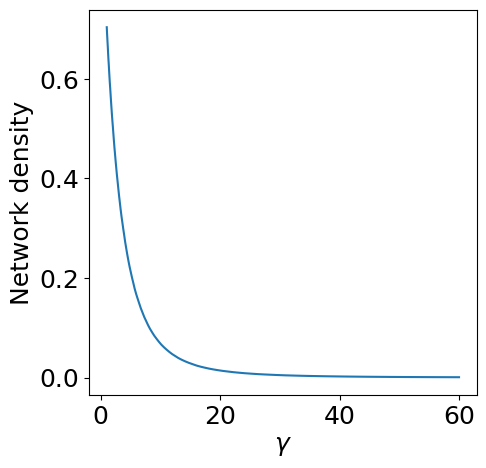

In [538]:
plt.figure(figsize=(5, 5))
plt.plot(gamma_values, np.mean(rho_mean, axis=0))
plt.xlabel('$\gamma$')
plt.ylabel('Network density')

Text(0, 0.5, 'Activity std')

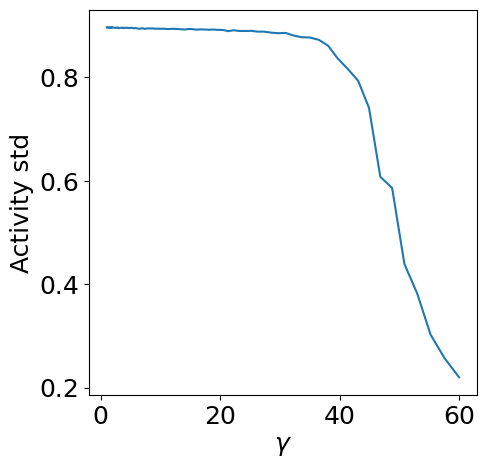

In [540]:
plt.figure(figsize=(5, 5))
plt.plot(gamma_values, np.mean(activity_std, axis=0))
plt.xlabel('$\gamma$')
plt.ylabel('Activity std')

Text(0, 0.5, 'Global correlation')

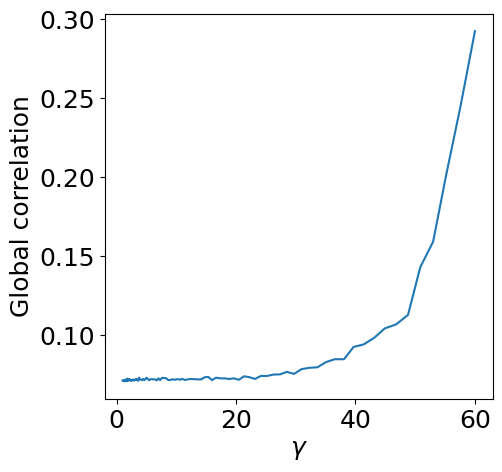

In [541]:
plt.figure(figsize=(5, 5))
plt.plot(gamma_values, np.mean(global_correlation, axis=0))
plt.xlabel('$\gamma$')
plt.ylabel('Global correlation')

59.99999999999997
50.851849784132895
39.67710830653867
29.70380921440379
19.642687588611007


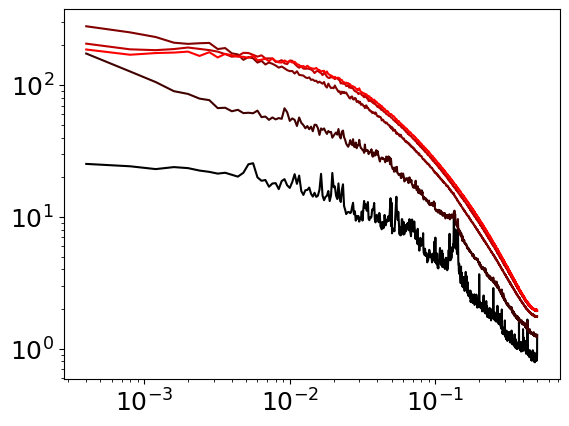

In [534]:
indices = [99, 95, 89, 82, 72]

colors = color_gradient([0, 0, 0], [1, 0, 0], len(indices))

for j, i in enumerate(indices):
    print(gamma_values[i])
    plt.plot(f, avg_spectra[i], color=colors[j])
    
plt.yscale('log')
plt.xscale('log')

In [529]:
matrix = compute_spectral_distance_matrix((avg_spectra))

Text(0, 0.5, 'Spectral distance')

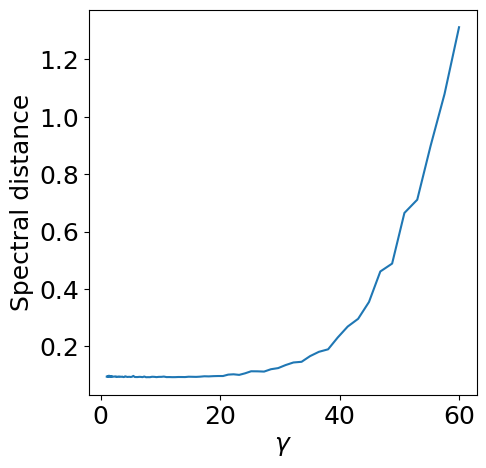

In [543]:
plt.figure(figsize=(5, 5))
plt.plot(gamma_values, np.mean(matrix, axis=0))
plt.xlabel('$\gamma$')
plt.ylabel('Spectral distance')

# 1.3 Generating example time series for figure

In [547]:
gammas = [60, 50, 40, 30, 20]

timeseries = []
for gamma in gammas:
    params['gamma'] = gamma
    simulator = Simulator(ellipse,
                          ChaoticRNN,
                          params)
    # Signal properties
    simulator.integrate(2500, output=False)
    timeseries.append(simulator.timeseries)

# 2. Generating figure

In [556]:
from scipy.stats import zscore

59.99999999999997
50.851849784132895
39.67710830653867
29.70380921440379
19.642687588611007


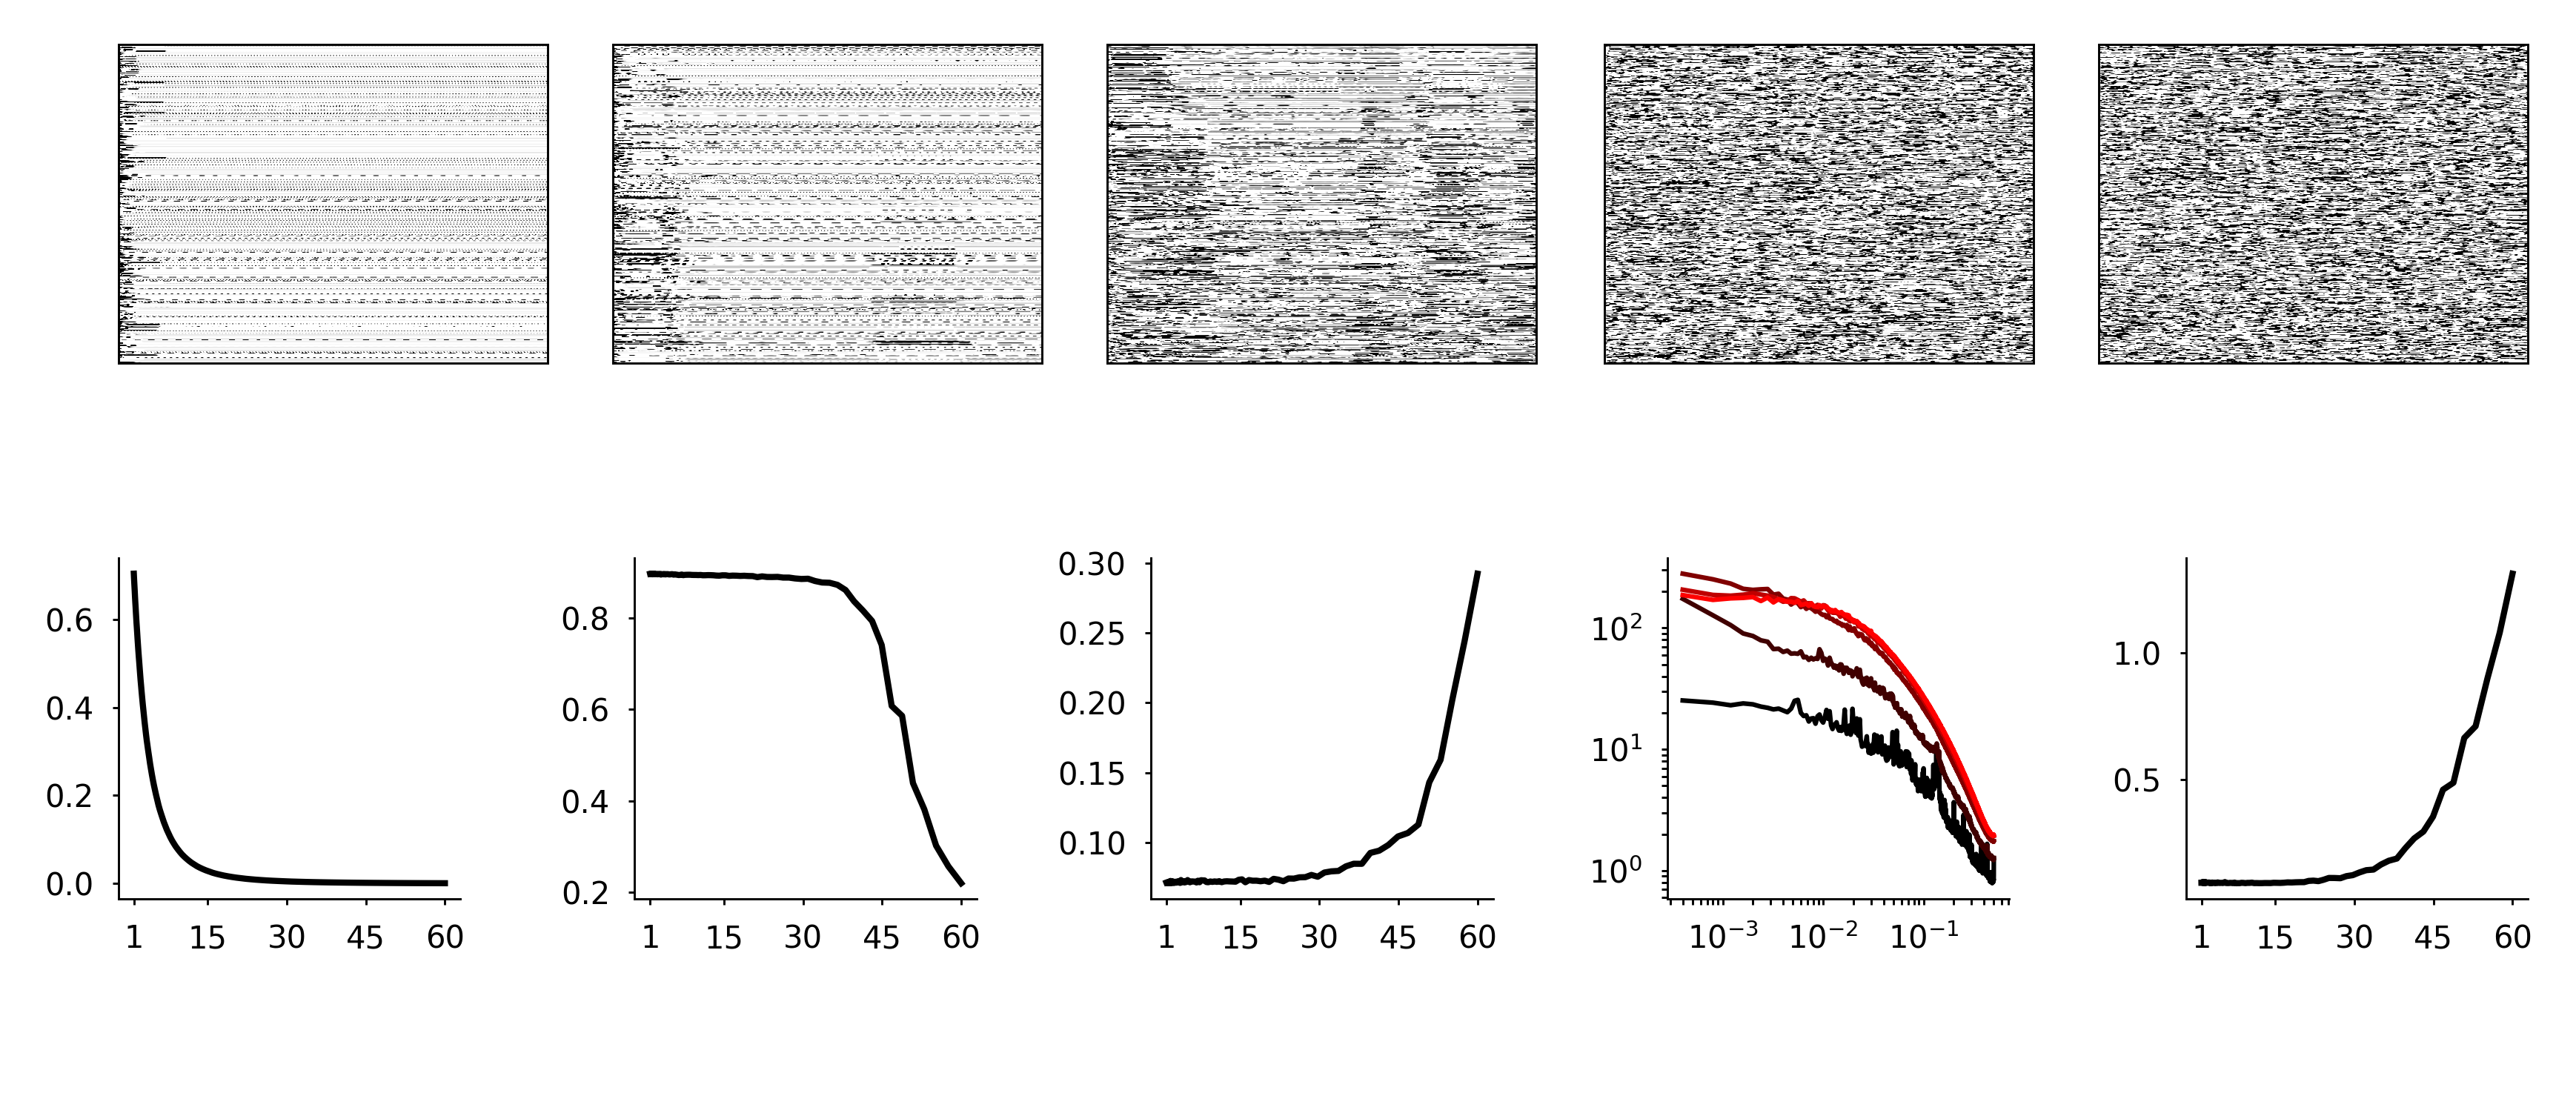

In [573]:
fig = PaperFigure(figsize=(7, 3), dpi=600)

fig.set_tick_length(1)
fig.set_font_size(5)
fig.add_background()

# Adding panels -------------------------------

w = 1.25
pad = (7 - 5 * w) / 4
for i in range(5):
    fig.add_axes(f'timeseries{i}', (i * (w + pad), 0), w, 0.75 * w)

w = 1
pad = (7 - 5 * w) / 4
fig.add_axes('density', (0 * (w + pad), 1.5), w, w)
fig.add_axes('std', (1 * (w + pad), 1.5), w, w)
fig.add_axes('correlation', (2 * (w + pad), 1.5), w, w)
fig.add_axes('spectra', (3 * (w + pad), 1.5), w, w)
fig.add_axes('distance', (4 * (w + pad), 1.5), w, w)

fig.set_line_thickness(0.35)

# Content -------------------------------------

for i in range(5):
    ax = fig.axes[f'timeseries{i}']
    ax.imshow(zscore(timeseries[i], axis=1)[:500, :1000], aspect='auto', cmap='binary', vmin=0, vmax=1)
    ax.set_xticks([])
    ax.set_yticks([])

ax = fig.axes['density']
ax.plot(gamma_values, np.mean(rho_mean, axis=0), color='black', linewidth=1)
ax.spines[['top', 'right']].set_visible(False)
ax.set_xticks([1, 15, 30, 45, 60])

ax = fig.axes['std']
ax.plot(gamma_values, np.mean(activity_std, axis=0), color='black', linewidth=1)
ax.spines[['top', 'right']].set_visible(False)
ax.set_xticks([1, 15, 30, 45, 60])

ax = fig.axes['correlation']
ax.plot(gamma_values, np.mean(global_correlation, axis=0), color='black', linewidth=1)
ax.spines[['top', 'right']].set_visible(False)
ax.set_xticks([1, 15, 30, 45, 60])

ax = fig.axes['spectra']
indices = [99, 95, 89, 82, 72]
colors = color_gradient([0, 0, 0], [1, 0, 0], len(indices))
for j, i in enumerate(indices):
    print(gamma_values[i])
    ax.plot(f, avg_spectra[i], color=colors[j], linewidth=0.75)
ax.spines[['top', 'right']].set_visible(False)
ax.set_xscale('log')
ax.set_yscale('log')

ax = fig.axes['distance']
ax.plot(gamma_values, np.mean(matrix, axis=0), color='black', linewidth=1)
ax.spines[['top', 'right']].set_visible(False)
ax.set_xticks([1, 15, 30, 45, 60])

# Displaying ----------------------------------

fig.show()

In [574]:
fig.save('../Figures/supp_dynamics_transitions_incomplete.svg')